# Project 4 - Object Detection with MobileNet-SSD
### DecodeLabs Industrial Training Kit

**Goal:** Implement a basic object detection task using a pre-trained model (Transfer Learning), perform recognition on a sample image, and display the output with a minimum confidence of 80%.

**Pipeline:**
1. Load the pre-trained MobileNet-SSD model
2. Load a sample image
3. Pre-process the image into a blob
4. Run a forward pass (prediction)
5. Filter detections by 80% confidence threshold
6. Scale coordinates back to real pixel values
7. Draw bounding boxes with labels
8. Display / save the final output

##  Install & Import Libraries

In [1]:
!pip install opencv-python numpy matplotlib

In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## Model Files (Pre-Trained - No Dataset Needed)

MobileNet-SSD was already trained by researchers on large image datasets (Transfer Learning). We just need to download and use its two files:

- `MobileNetSSD_deploy.prototxt` (model architecture)
- `MobileNetSSD_deploy.caffemodel` (pre-trained weights)

Place both inside a `models/` folder next to this notebook. See `README.md` for download links.

These 21 classes are what the model can recognize:

In [4]:
CLASSES = [
    "background", "aeroplane", "bicycle", "bird", "boat",
    "bottle", "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

CONFIDENCE_THRESHOLD = 0.80  # Project 4 requirement: minimum 80%

np.random.seed(42)
COLORS = np.random.uniform(0, 255, size=(len(CLASSES), 3))

PROTOTXT_PATH = "models/MobileNetSSD_deploy.prototxt"
MODEL_PATH = "models/MobileNetSSD_deploy.caffemodel"

## Load the Pre-Trained Model

In [9]:
import os
print("Current working directory:", os.getcwd())
print(os.listdir())

Current working directory: C:\Users\AL REHMAN LAPTOPS\Documents\Object Detection (MobileNet-SSD)
['.ipynb_checkpoints', 'app.py', 'detector.py', 'models', 'Project4_Object_Detection.ipynb', 'README.md', 'requirements.txt']


In [10]:
net = cv2.dnn.readNetFromCaffe(PROTOTXT_PATH, MODEL_PATH)
print("Model loaded successfully.")

Model loaded successfully.


## Load a Sample Image

In [12]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'detector.py', 'models', 'Project4_Object_Detection.ipynb', 'README.md', 'requirements.txt']


Image loaded. Dimensions: width=8256, height=5504


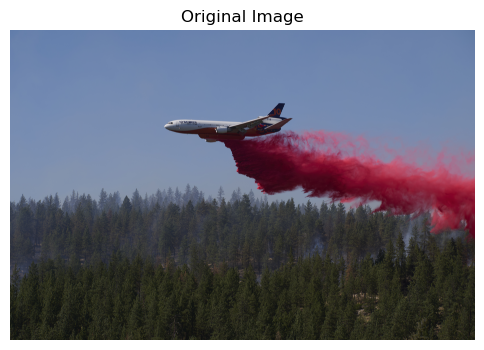

In [27]:
# change this to your sample image path
IMAGE_PATH = "image3.jpg"

image = cv2.imread(IMAGE_PATH)
if image is None:
    raise FileNotFoundError(f"Could not read image at {IMAGE_PATH}. Check the path.")

(h, w) = image.shape[:2]
print(f"Image loaded. Dimensions: width={w}, height={h}")

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

## Pre-Processing - Blob Construction

The network doesn't understand a raw image directly. We convert it into a 4D "blob":
- Resize to 300x300 (MobileNet-SSD's required input size)
- Mean subtraction (normalization)
- Scale pixel values

In [22]:
blob = cv2.dnn.blobFromImage(
    cv2.resize(image, (300, 300)),
    0.007843,      # scale factor
    (300, 300),    # spatial size expected by the network
    127.5          # mean subtraction value
)

print("Blob shape:", blob.shape)  # Expected: (1, 3, 300, 300)

Blob shape: (1, 3, 300, 300)


## Forward Pass - Run the Prediction

In [23]:
net.setInput(blob)
detections = net.forward()

print("Detections shape:", detections.shape)
print("Total raw detections:", detections.shape[2])

Detections shape: (1, 1, 100, 7)
Total raw detections: 100


## Confidence Filtering (80% Gate) + Coordinate Scaling

Every detection has a confidence score. We only keep detections with confidence >= 80%, per project requirements. We then scale the normalized coordinates using the original image's width/height.

In [24]:
results = []

for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence >= CONFIDENCE_THRESHOLD:
        idx = int(detections[0, 0, i, 1])
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")

        results.append({
            "label": CLASSES[idx] if idx < len(CLASSES) else "unknown",
            "confidence": float(confidence),
            "box": (int(startX), int(startY), int(endX), int(endY))
        })

print(f"Accepted detections (>= {int(CONFIDENCE_THRESHOLD*100)}% confidence): {len(results)}")
for r in results:
    print(r)

Accepted detections (>= 80% confidence): 1
{'label': 'aeroplane', 'confidence': 0.8887037634849548, 'box': (2780, 1257, 5125, 2010)}


## Draw Bounding Boxes (Visual Confirmation)

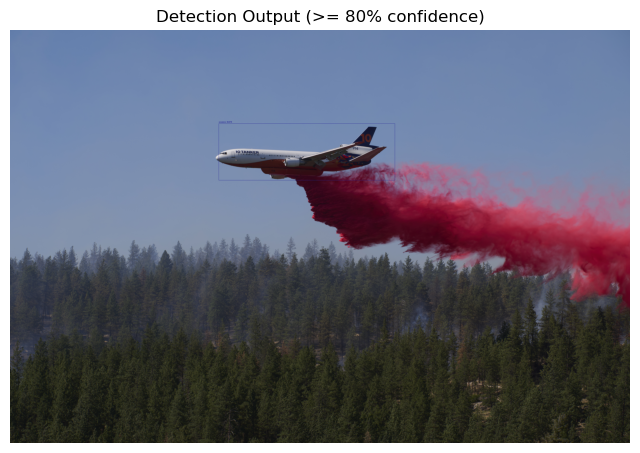

In [25]:
output = image.copy()

for det in results:
    (startX, startY, endX, endY) = det["box"]
    idx = CLASSES.index(det["label"]) if det["label"] in CLASSES else 0
    color = COLORS[idx]

    label_text = "{}: {:.2f}%".format(det["label"], det["confidence"] * 100)

    cv2.rectangle(output, (startX, startY), (endX, endY), color, 2)
    y = startY - 15 if startY - 15 > 15 else startY + 15
    cv2.putText(output, label_text, (startX, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detection Output (>= 80% confidence)")
plt.axis("off")
plt.show()

## Save the Output Image

In [26]:
output_path = "output_detected.jpg"
cv2.imwrite(output_path, output)
print(f"Output saved to: {output_path}")

Output saved to: output_detected.jpg


## Conclusion

This notebook demonstrates the full Project 4 - pipeline:
- Pre-trained model loaded (no dataset/training used - Transfer Learning)
- Image pre-processed into a blob
- Forward pass performed
- Only detections with confidence >= 80% accepted (Gatekeeper Rule)
- Coordinates scaled and bounding boxes drawn for visual confirmation

The reusable version of this logic lives in `detector.py`, which is also used by `app.py` (the Streamlit demo app).